# 06 — Customer Segmentation (KMeans)

**Purpose:** Model 3. Cluster customers on RFM + return behavior. Elbow + silhouette to
choose k. Profile each cluster. Visualize with PCA. Export segment labels.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import mlflow

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5), 'figure.dpi': 110,
    'axes.facecolor': '#1a1d27', 'figure.facecolor': '#0f1117',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#e8eaf0',
    'xtick.color': '#8b92a8', 'ytick.color': '#8b92a8',
    'text.color': '#e8eaf0', 'grid.color': '#2e3347', 'grid.alpha': 0.5,
})

mlflow.set_tracking_uri('../mlflow/mlruns')
mlflow.set_experiment('retail-returns-intelligence')
print('Setup OK')

Setup OK


In [2]:
customer_features = pd.read_parquet('../data/processed/customer_features.parquet')

seg_cols = [c for c in customer_features.columns
            if c not in ('customer_id',) and customer_features[c].dtype in (float, int)
            and customer_features[c].notnull().all()]

X_seg = customer_features[seg_cols].fillna(customer_features[seg_cols].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

print(f'Customers for segmentation: {len(X_seg):,}')
print(f'Segmentation features: {seg_cols}')

Customers for segmentation: 5,881
Segmentation features: ['total_orders', 'total_revenue', 'unique_categories_purchased', 'total_return_orders', 'total_return_value', 'unique_categories_returned', 'n_weekend_returns', 'lifetime_return_rate', 'return_value_ratio', 'weekend_return_share', 'tenure_days', 'recency_score', 'frequency_score', 'monetary_score', 'return_velocity']


## 1. Elbow method + silhouette scores

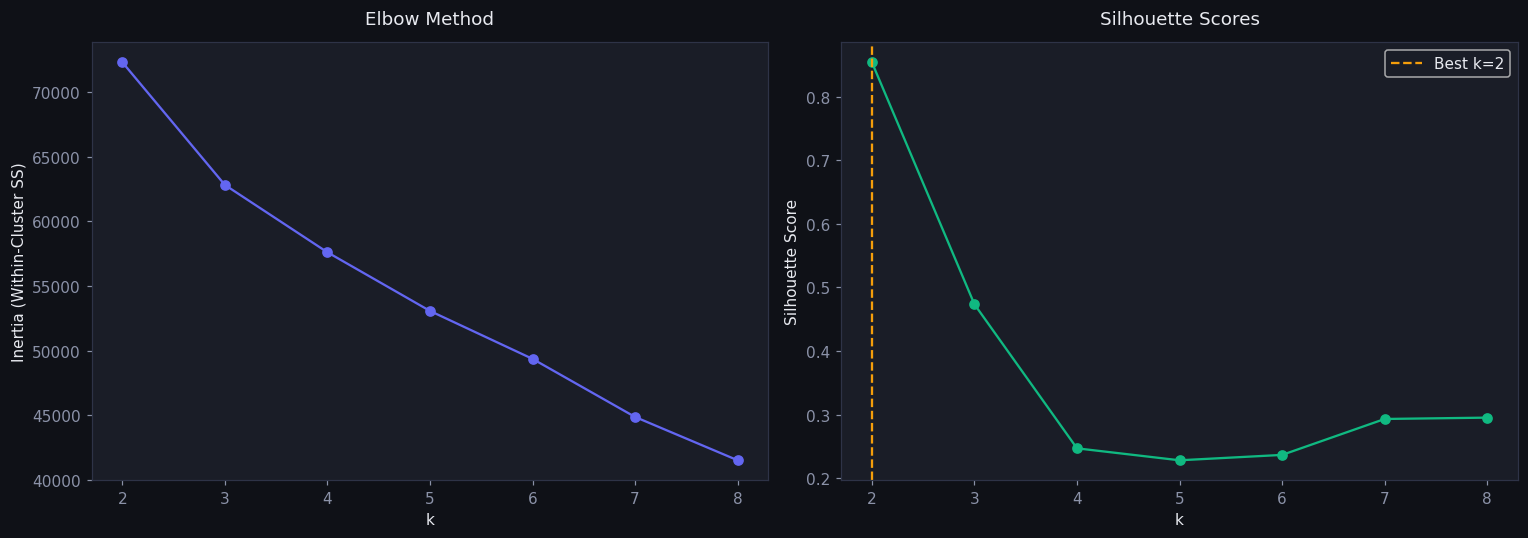

Best k by silhouette: 2
 k      inertia  silhouette
 2 72289.720107    0.854082
 3 62808.838888    0.473516
 4 57603.876790    0.247094
 5 53072.751541    0.228292
 6 49367.511846    0.236759
 7 44880.316920    0.293255
 8 41532.850682    0.295358


In [3]:
K_range = range(2, 9)
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=min(2000, len(X_scaled))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'o-', color='#6366f1')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].set_title('Elbow Method', pad=12)

axes[1].plot(list(K_range), sil_scores, 'o-', color='#10b981')
best_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='#f59e0b', linestyle='--', label=f'Best k={best_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores', pad=12); axes[1].legend()

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/06_elbow_silhouette.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f'Best k by silhouette: {best_k}')
print(pd.DataFrame({'k': list(K_range), 'inertia': inertias, 'silhouette': sil_scores}).to_string(index=False))

## 2. Fit final KMeans (k=4 per project brief, but use best_k for reference)

In [4]:
# k=4 is the target per project brief; best_k from silhouette informs us if 4 is reasonable
FINAL_K = 4

with mlflow.start_run(run_name='kmeans-segmentation'):
    mlflow.log_params({'k': FINAL_K, 'features': str(seg_cols)})
    km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
    cluster_labels = km_final.fit_predict(X_scaled)
    sil_final = silhouette_score(X_scaled, cluster_labels, sample_size=min(2000, len(X_scaled)))
    mlflow.log_metric('silhouette_score', sil_final)

print(f'Final KMeans k={FINAL_K}, Silhouette: {sil_final:.4f}')
print('Cluster sizes:')
print(pd.Series(cluster_labels).value_counts().sort_index().rename('count').to_string())

Final KMeans k=4, Silhouette: 0.2378
Cluster sizes:
0    1937
1     659
2    3267
3      18


## 3. Cluster profiling

In [5]:
df_seg = customer_features[seg_cols].fillna(customer_features[seg_cols].median()).copy()
df_seg['cluster'] = cluster_labels

# Centroids in original scale
centroids = df_seg.groupby('cluster')[seg_cols].mean()
print('Cluster centroids (original scale):')
print(centroids.round(3).to_string())

# Assign human-readable labels based on centroid inspection
# Map cluster with highest return rate to 'High Returner', lowest to 'Premium Loyal', etc.
if 'cust_return_rate' in centroids.columns:
    rr_col = 'cust_return_rate'
elif 'return_rate' in centroids.columns:
    rr_col = 'return_rate'
else:
    rr_col = seg_cols[0]

ranked = centroids[rr_col].rank(ascending=False).astype(int)
print(f'\nClusters ranked by {rr_col} (1=highest):')
print(ranked.to_string())

Cluster centroids (original scale):
         total_orders  total_revenue  unique_categories_purchased  total_return_orders  total_return_value  unique_categories_returned  n_weekend_returns  lifetime_return_rate  return_value_ratio  weekend_return_share  tenure_days  recency_score  frequency_score  monetary_score  return_velocity
cluster                                                                                                                                                                                                                                                                                                
0               2.290        831.318                       36.191                0.534             117.148                       1.011              0.024                 0.224               0.053                 0.015      566.308        463.069            2.290         831.318            0.002
1              21.434      10925.928                      245.901           

## 4. PCA visualisation

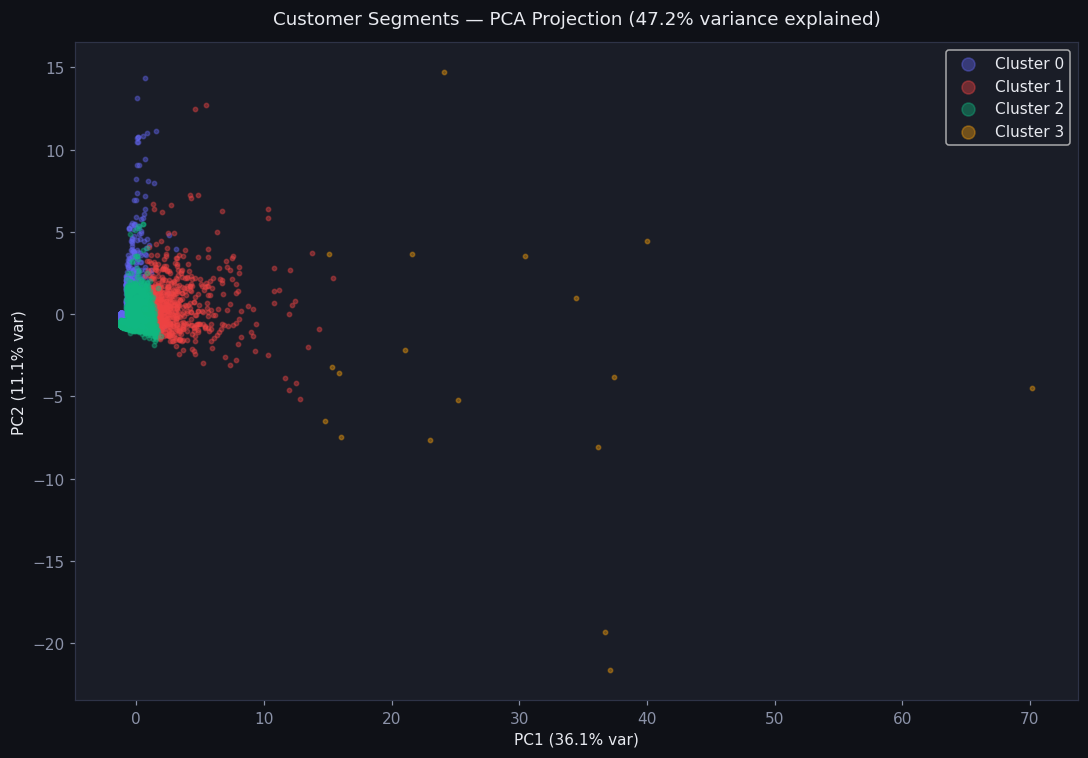

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_.sum()

palette = ['#6366f1', '#ef4444', '#10b981', '#f59e0b']

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(FINAL_K):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=8, alpha=0.4, c=palette[c], label=f'Cluster {c}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title(f'Customer Segments — PCA Projection ({var_explained:.1%} variance explained)', pad=12)
ax.legend(markerscale=3)

plt.tight_layout()
plt.savefig('../figures/06_pca_clusters.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 5. Save model and segment assignments

In [7]:
os.makedirs('../models', exist_ok=True)
joblib.dump(km_final, '../models/segmentation_kmeans.joblib')
joblib.dump(scaler,   '../models/segmentation_scaler.joblib')

# Segment assignment table
seg_df = customer_features[['customer_id']].copy()
seg_df['cluster'] = cluster_labels
seg_df['pca_x']   = X_pca[:, 0]
seg_df['pca_y']   = X_pca[:, 1]
seg_df.to_parquet('../data/processed/customer_segments.parquet', index=False)

print(f'Saved: segmentation_kmeans.joblib, segmentation_scaler.joblib')
print(f'Saved: customer_segments.parquet ({len(seg_df):,} rows)')
print(f'Silhouette score: {sil_final:.4f}')

Saved: segmentation_kmeans.joblib, segmentation_scaler.joblib
Saved: customer_segments.parquet (5,881 rows)
Silhouette score: 0.2378
